# Weather Data Analysis

In this project I analyze a weather dataset to understand temperature and rainfall patterns.

Steps done in this project:
- Data cleaning
- Creating new columns (month and season)
- Visualizing rainfall and temperature trends
- Finding some insights from the data

## Import Libraries

In this step, the required Python libraries are imported.

- **Pandas** is used for data manipulation and analysis.

- **matplotlib** is used for data visualization.



In [67]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

The weather dataset is loaded using pandas.  
This dataset contains information about date, city, temperature, and rainfall.

In [68]:
df = pd.read_csv("weather.csv")

## Data Understanding

Before performing analysis, we examine the structure of the dataset.

This includes:
- Checking column data types
- Viewing the first few rows
- Identifying missing values

In [69]:
print(df.info())
print(df.isnull().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         15 non-null     object 
 1   city         15 non-null     object 
 2   temperature  12 non-null     float64
 3   rainfall     15 non-null     int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 612.0+ bytes
None
date           0
city           0
temperature    3
rainfall       0
dtype: int64
       temperature   rainfall
count    12.000000  15.000000
mean     31.666667   1.133333
std       1.669694   1.302013
min      29.000000   0.000000
25%      30.000000   0.000000
50%      32.000000   1.000000
75%      33.000000   2.000000
max      34.000000   4.000000


## Data Cleaning

Missing temperature values are handled by replacing them with the mean temperature.  
This helps maintain data consistency and avoids issues during analysis.

In [70]:
df["temperature"] = df["temperature"].fillna(df["temperature"].mean().round(2))
print(df.isnull().sum())

date           0
city           0
temperature    0
rainfall       0
dtype: int64


## Convert Date Column

Convert date column into datetime format.

In [71]:
df["date"] = pd.to_datetime(df["date"])
print(df.dtypes)

date           datetime64[ns]
city                   object
temperature           float64
rainfall                int64
dtype: object


/tmp/ipykernel_327/2990847675.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


## Feature Engineering

Create new columns such as month and season.

In [72]:
df["month"] = df["date"].dt.month
print(df.head())

df["season"] = df["month"].apply(
    lambda x: "Winter" if x in [12,1,2]
    else "Summer" if x in [3,4,5]
    else "Monsoon" if x in [6,7,8,9]
    else "Post-Monsoon")

        date     city  temperature  rainfall  month
0 2026-01-01  Chennai        29.00         2      1
1 2026-03-02  Chennai        30.00         0      3
2 2026-05-03  Chennai        31.67         2      5
3 2026-03-04  Chennai        30.00         3      3
4 2026-04-05  Chennai        32.00         0      4


## Sort Data by Date

In [73]:
df = df.sort_values("date")
print(df[["date","rainfall"]])

         date  rainfall
0  2026-01-01         2
8  2026-01-09         2
14 2026-01-15         0
5  2026-02-06         0
6  2026-02-07         1
1  2026-03-02         0
3  2026-03-04         3
7  2026-03-08         4
10 2026-03-11         1
12 2026-03-13         0
13 2026-03-14         2
4  2026-04-05         0
2  2026-05-03         2
11 2026-06-12         0
9  2026-10-10         0


## Save Clean Dataset

In [74]:
df.to_csv("clean_weather.csv", index=False)

## Data Visualization

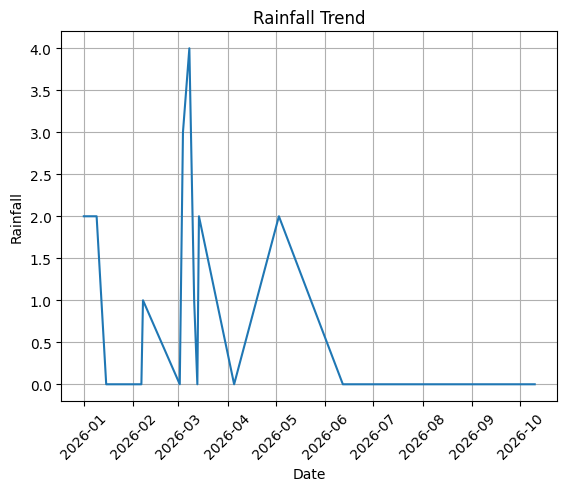

In [75]:
plt.plot(df["date"], df["rainfall"])

plt.title("Rainfall Trend")
plt.xlabel("Date")
plt.ylabel("Rainfall")


plt.xticks(rotation=45)
plt.grid(True)

plt.show()

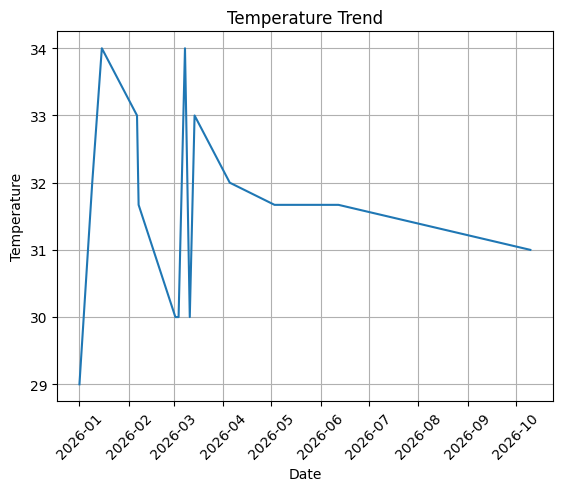

In [76]:
plt.plot(df["date"], df["temperature"])

plt.title("Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## Temperature vs Rainfall

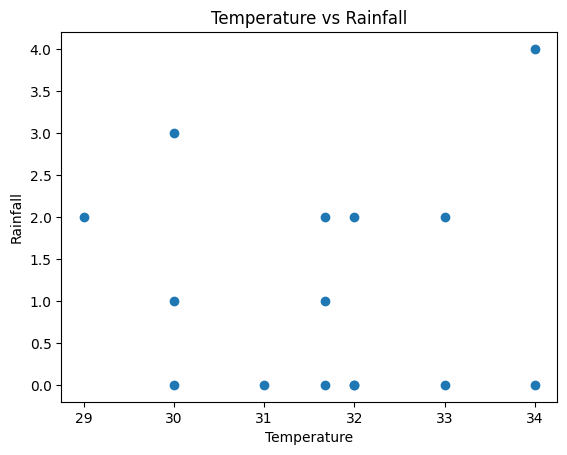

             temperature  rainfall
temperature     1.000000  0.024662
rainfall        0.024662  1.000000


In [77]:
plt.scatter(df["temperature"], df["rainfall"])

plt.title("Temperature vs Rainfall")

plt.xlabel("Temperature")
plt.ylabel("Rainfall")

plt.show()

print(df[["temperature","rainfall"]].corr())

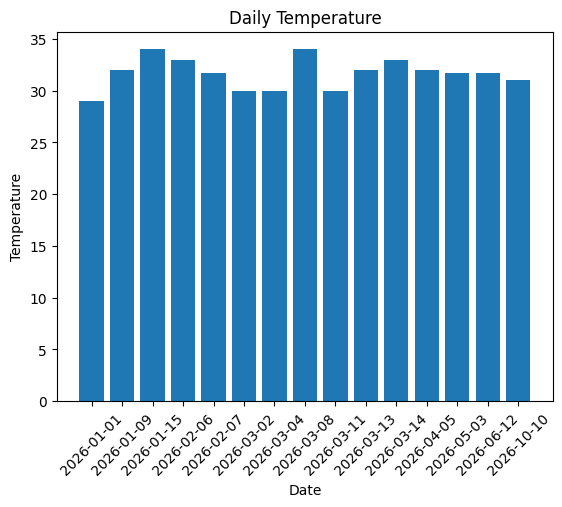

In [78]:
plt.bar(df["date"].astype(str), df["temperature"])

plt.title("Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")

plt.xticks(rotation=45)

plt.show()

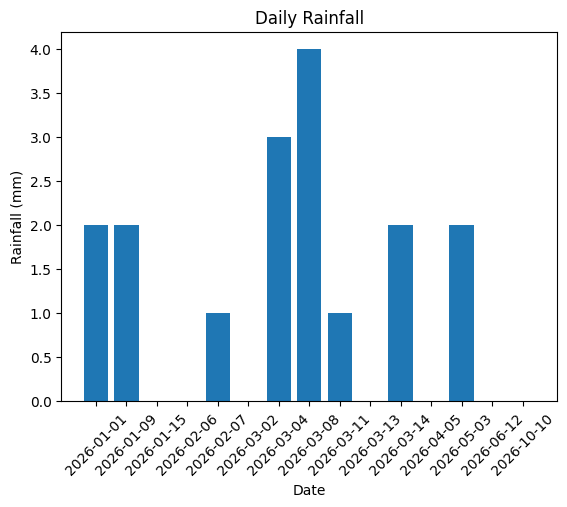

In [79]:
plt.bar(df["date"].astype(str), df["rainfall"])

plt.title("Daily Rainfall")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")

plt.xticks(rotation=45)

plt.show()

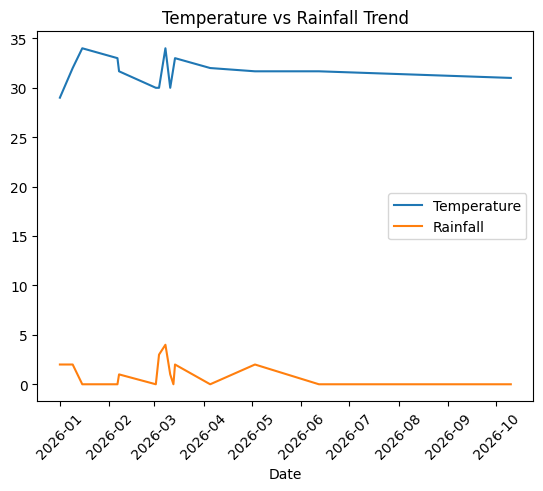

In [80]:
plt.plot(df["date"], df["temperature"], label="Temperature")
plt.plot(df["date"], df["rainfall"], label="Rainfall")

plt.title("Temperature vs Rainfall Trend")
plt.xlabel("Date")

plt.xticks(rotation=45)

plt.legend()
plt.show()

## Temperature Statistics

In [81]:
print("Max Temperature:", df["temperature"].max())
print("Min Temperature:", df["temperature"].min())

Max Temperature: 34.0
Min Temperature: 29.0


## Extreme Rainfall Analysis

1.   List item
2.   List item



In [82]:
print(df.loc[df["rainfall"].idxmax()])
print(df.loc[df["rainfall"].idxmin()])

date           2026-03-08 00:00:00
city                       Chennai
temperature                   34.0
rainfall                         4
month                            3
season                      Summer
Name: 7, dtype: object
date           2026-01-15 00:00:00
city                       Chennai
temperature                   34.0
rainfall                         0
month                            1
season                      Winter
Name: 14, dtype: object


## Top 3 Hottest Days

In [83]:
top3 = df.sort_values(by="temperature", ascending=False).head(3)
print(top3)

         date     city  temperature  rainfall  month  season
14 2026-01-15  Chennai         34.0         0      1  Winter
7  2026-03-08  Chennai         34.0         4      3  Summer
5  2026-02-06  Chennai         33.0         0      2  Winter


## Key Insights

- The rainfall trend chart shows how rainfall changes across different dates.
- The temperature trend chart helps identify warmer and cooler periods.
- The scatter plot shows that rainfall and temperature do not always increase together.
- The hottest days were identified by sorting the temperature values.
- The highest rainfall day shows the most intense rainfall event in the dataset.